# NY Taxi Fare Prediction: Exploratory Data Analysis
## Step 0: Install dependencies


In [49]:
%pip install pandas matplotlib seaborn plotly scikit-learn pyarrow fastparquet

Note: you may need to restart the kernel to use updated packages.



## Step 1: Understand the raw dataset

In this step we will:

1. Locate the May 2022 Parquet file.
2. Inspect the file metadata without loading the entire dataset.
3. Read one row group as a representative sample.
4. Check the columns, data types, missing values, and basic numeric ranges.

We are only observing the data at this stage. Cleaning, filtering, and feature engineering come later.

In [50]:
from pathlib import Path

import pandas as pd
import pyarrow.parquet as pq

# Make the notebook work whether it is launched from the project root or notebooks/.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "raw" / "yellow_tripdata_2022-05.parquet"

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path}")

print(f"Dataset: {data_path}")
print(f"File size: {data_path.stat().st_size / 1024**2:.1f} MB")

Dataset: /Users/clausfuss/Documents/Personal/AnyOne AI/Final Project/group/tfp/data/raw/yellow_tripdata_2022-05.parquet
File size: 69.1 MB


In [51]:
parquet_file = pq.ParquetFile(data_path)

print(f"Rows in file: {parquet_file.metadata.num_rows:,}")
print(f"Columns in file: {parquet_file.metadata.num_columns}")
print(f"Row groups: {parquet_file.num_row_groups}")

print("\nSchema:")
print(parquet_file.schema)

Rows in file: 3,588,295
Columns in file: 19
Row groups: 4

Schema:
required group field_id=-1 schema {
  optional int64 field_id=-1 VendorID;
  optional int64 field_id=-1 tpep_pickup_datetime (Timestamp(isAdjustedToUTC=false, timeUnit=microseconds, is_from_converted_type=false, force_set_converted_type=false));
  optional int64 field_id=-1 tpep_dropoff_datetime (Timestamp(isAdjustedToUTC=false, timeUnit=microseconds, is_from_converted_type=false, force_set_converted_type=false));
  optional double field_id=-1 passenger_count;
  optional double field_id=-1 trip_distance;
  optional double field_id=-1 RatecodeID;
  optional binary field_id=-1 store_and_fwd_flag (String);
  optional int64 field_id=-1 PULocationID;
  optional int64 field_id=-1 DOLocationID;
  optional int64 field_id=-1 payment_type;
  optional double field_id=-1 fare_amount;
  optional double field_id=-1 extra;
  optional double field_id=-1 mta_tax;
  optional double field_id=-1 tip_amount;
  optional double field_id=-1 to

### Using just one row group for initial exploration

The May 2022 file contains millions of trips. Reading only the first row group gives us enough data to understand the structure while keeping memory usage reasonable. The metadata above gives the exact total row count.

In [52]:
sample = parquet_file.read_row_group(0).to_pandas()

print(f"Sample shape: {sample.shape}")
sample.head()

Sample shape: (1048576, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-05-01 00:00:36,2022-05-01 00:19:18,1.0,4.1,1.0,N,246,151,2,17.0,3.0,0.5,0.00,0.0,0.3,20.80,2.5,0.0
1,1,2022-05-01 00:27:44,2022-05-01 00:41:33,1.0,2.3,1.0,N,238,74,2,11.0,3.0,0.5,0.00,0.0,0.3,14.80,2.5,0.0
2,1,2022-05-01 00:59:00,2022-05-01 01:14:22,1.0,4.2,1.0,N,163,260,2,15.5,3.0,0.5,0.00,0.0,0.3,19.30,2.5,0.0
3,1,2022-05-01 00:48:18,2022-05-01 01:28:02,1.0,0.0,1.0,N,79,182,1,41.2,0.0,0.5,0.00,0.0,0.3,42.00,0.0,0.0
4,1,2022-05-01 00:28:26,2022-05-01 00:37:49,1.0,1.6,1.0,N,238,75,1,7.5,3.0,0.5,2.25,0.0,0.3,13.55,2.5,0.0


In [53]:
print("Data types:")
display(sample.dtypes.to_frame("dtype"))

print("Missing values in the sample:")
missing = (
    sample.isna()
    .sum()
    .to_frame("missing_count")
)
missing["missing_percent"] = missing["missing_count"] / len(sample) * 100
display(missing.sort_values("missing_count", ascending=False))

Data types:


,dtype
VendorID,int64
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
RatecodeID,float64
store_and_fwd_flag,str
PULocationID,int64
DOLocationID,int64
payment_type,int64


Missing values in the sample:


,missing_count,missing_percent
VendorID,0,0.0
fare_amount,0,0.0
congestion_surcharge,0,0.0
total_amount,0,0.0
improvement_surcharge,0,0.0
tolls_amount,0,0.0
tip_amount,0,0.0
mta_tax,0,0.0
extra,0,0.0
payment_type,0,0.0


In [54]:
numeric_summary = sample.describe(include="number").T
numeric_summary["zero_count"] = (sample[numeric_summary.index] == 0).sum()
numeric_summary["negative_count"] = (sample[numeric_summary.index] < 0).sum()
display(numeric_summary)

min_po_date = sample["tpep_pickup_datetime"].min()
max_po_date = sample["tpep_pickup_datetime"].max()
min_do_date = sample["tpep_dropoff_datetime"].min()
max_do_date = sample["tpep_dropoff_datetime"].max()
print(f"Pickup datetime range: {min_po_date} to {max_po_date}")
print(f"Dropoff datetime range: {min_do_date} to {max_do_date}")

,count,mean,std,min,25%,50%,75%,max,zero_count,negative_count
VendorID,1048576.0,1.696456,0.459788,1.00,1.00,2.00,2.00,2.00,0,0
passenger_count,1048576.0,1.382376,0.948134,0.00,1.00,1.00,1.00,8.00,22064,0
trip_distance,1048576.0,3.549979,29.105174,0.00,1.10,1.88,3.50,29445.65,12987,0
RatecodeID,1048576.0,1.380363,5.414365,1.00,1.00,1.00,1.00,99.00,0,0
PULocationID,1048576.0,165.095862,65.030135,1.00,132.00,162.00,234.00,265.00,0,0
DOLocationID,1048576.0,163.470818,69.946278,1.00,114.00,162.00,234.00,265.00,0,0
payment_type,1048576.0,1.226617,0.459920,1.00,1.00,1.00,1.00,4.00,0,0
fare_amount,1048576.0,14.496153,13.949598,-500.00,7.00,10.00,16.00,500.00,438,6042
extra,1048576.0,1.040327,1.260542,-4.50,0.00,0.50,2.50,8.55,431878,2672
mta_tax,1048576.0,0.489387,0.089491,-0.50,0.50,0.50,0.50,0.50,10451,5903


Pickup datetime range: 2008-12-31 23:02:08 to 2022-05-12 20:35:00
Dropoff datetime range: 2008-12-31 23:59:34 to 2022-05-12 20:55:07


## Insights from Step 1

Record these observations for the team:

- How many total trips are in the file?  
  
  3,588,295 trips in the May 2022 file.

- Which columns contain missing values? 
  
  For group 0, there are no missing values in any of the columns.

- Do any numeric columns contain negative or zero values that may need investigation?

  Yes.   We should take a closer look to the following columns:

      passenger_count: 22,064 rows with 0 values
      trip_distance: 12,987 rows with 0 values
      fare_amount: 438 row with with 0 values 
 
      total_amount: 6,115 with negative values
      fare_amount: 6,042 with negative values
      mta_tax: 5,903 with negative values
      improvement_surcharge: 6,114 with negative values

- Are the pickup and dropoff timestamps stored as datetime values?

  Yes, they are stored as datetime values.  but also some suspicious values are present, such as 2008-12-31.  We should investigate if these are valid timestamps or if they indicate missing or default values.

- Which columns are potential prediction inputs, and which columns are only known after the ride?
  
  Variables known before the ride include: 
  
  PULocationID,
  DOLocationID,
  trip_distance,
  tpep_pickup_datetime,
  passenger_count,
  RatecodeID

  Variables to avoid to prevent data leakage include:

  tpep_dropoff_datetime,
  tip_amount,
  tolls_amount,
  total_amount,
  payment_type,
  extra,
  mta_tax,
  improvement_surcharge,
  congestion_surcharge,
  airport_fee

## Step 2: Investigate data quality issues

In this step we will inspect suspicious records without removing them yet.

We will check:

1. Whether pickup and dropoff dates belong to May 2022.
2. Whether trip duration is positive and plausible.
3. Whether distance and fare values are positive.
4. Whether the implied average speed contains unusual values.

The goal is to measure the problems first so that the cleaning rules can be justified.

In [55]:
quality_sample = sample.copy()

quality_sample["duration_minutes"] = (
    quality_sample["tpep_dropoff_datetime"]
    - quality_sample["tpep_pickup_datetime"]
).dt.total_seconds() / 60

may_start = pd.Timestamp("2022-05-01")
next_month = pd.Timestamp("2022-06-01")
quality_sample["pickup_outside_may"] = (
    (quality_sample["tpep_pickup_datetime"] < may_start)
    | (quality_sample["tpep_pickup_datetime"] >= next_month)
)
quality_sample["dropoff_outside_may"] = (
    (quality_sample["tpep_dropoff_datetime"] < may_start)
    | (quality_sample["tpep_dropoff_datetime"] >= next_month)
)
quality_sample["non_positive_duration"] = quality_sample["duration_minutes"] <= 0
quality_sample["duration_over_3_hours"] = quality_sample["duration_minutes"] > 180
quality_sample["non_positive_distance"] = quality_sample["trip_distance"] <= 0
quality_sample["non_positive_fare"] = quality_sample["fare_amount"] <= 0

quality_sample["average_speed_mph"] = (
    quality_sample["trip_distance"]
    / (quality_sample["duration_minutes"] / 60)
).where(quality_sample["duration_minutes"] > 0)
quality_sample["speed_over_80_mph"] = quality_sample["average_speed_mph"] > 80

quality_sample.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,airport_fee,duration_minutes,pickup_outside_may,dropoff_outside_may,non_positive_duration,duration_over_3_hours,non_positive_distance,non_positive_fare,average_speed_mph,speed_over_80_mph
0,1,2022-05-01 00:00:36,2022-05-01 00:19:18,1.0,4.1,1.0,N,246,151,2,...,0.0,18.700000,False,False,False,False,False,False,13.155080,False
1,1,2022-05-01 00:27:44,2022-05-01 00:41:33,1.0,2.3,1.0,N,238,74,2,...,0.0,13.816667,False,False,False,False,False,False,9.987937,False
2,1,2022-05-01 00:59:00,2022-05-01 01:14:22,1.0,4.2,1.0,N,163,260,2,...,0.0,15.366667,False,False,False,False,False,False,16.399132,False
3,1,2022-05-01 00:48:18,2022-05-01 01:28:02,1.0,0.0,1.0,N,79,182,1,...,0.0,39.733333,False,False,False,False,True,False,0.000000,False
4,1,2022-05-01 00:28:26,2022-05-01 00:37:49,1.0,1.6,1.0,N,238,75,1,...,0.0,9.383333,False,False,False,False,False,False,10.230906,False


In [56]:
quality_checks = pd.Series(
    {
        "pickup_outside_may": quality_sample["pickup_outside_may"].sum(),
        "dropoff_outside_may": quality_sample["dropoff_outside_may"].sum(),
        "non_positive_duration": quality_sample["non_positive_duration"].sum(),
        "duration_over_3_hours": quality_sample["duration_over_3_hours"].sum(),
        "non_positive_distance": quality_sample["non_positive_distance"].sum(),
        "non_positive_fare": quality_sample["non_positive_fare"].sum(),
        "speed_over_80_mph": quality_sample["speed_over_80_mph"].sum(),
    },
    name="problematic_rows",
).to_frame()

quality_checks["percent_of_sample"] = quality_checks["problematic_rows"] / len(quality_sample) * 100
display(quality_checks.sort_values("problematic_rows", ascending=False))

print("Duration summary in minutes:")
display(quality_sample["duration_minutes"].describe())

print("Average speed summary in mph:")
display(quality_sample["average_speed_mph"].describe())

print(quality_sample.describe(include="number").T)

,problematic_rows,percent_of_sample
non_positive_distance,12987,1.238537
non_positive_fare,6480,0.617981
duration_over_3_hours,1496,0.142670
speed_over_80_mph,1018,0.097084
non_positive_duration,463,0.044155
pickup_outside_may,108,0.010300
dropoff_outside_may,28,0.002670


Duration summary in minutes:


count    1.048576e+06
mean     1.736061e+01
std      5.252438e+01
min      0.000000e+00
25%      7.316667e+00
50%      1.201667e+01
75%      1.943333e+01
max      6.823550e+03
Name: duration_minutes, dtype: float64

Average speed summary in mph:


count    1.048113e+06
mean     1.511464e+01
std      3.283264e+02
min      0.000000e+00
25%      7.758621e+00
50%      1.028017e+01
75%      1.421207e+01
max      1.603697e+05
Name: average_speed_mph, dtype: float64

                           count        mean         std     min         25%  \
VendorID               1048576.0    1.696456    0.459788    1.00    1.000000   
passenger_count        1048576.0    1.382376    0.948134    0.00    1.000000   
trip_distance          1048576.0    3.549979   29.105174    0.00    1.100000   
RatecodeID             1048576.0    1.380363    5.414365    1.00    1.000000   
PULocationID           1048576.0  165.095862   65.030135    1.00  132.000000   
DOLocationID           1048576.0  163.470818   69.946278    1.00  114.000000   
payment_type           1048576.0    1.226617    0.459920    1.00    1.000000   
fare_amount            1048576.0   14.496153   13.949598 -500.00    7.000000   
extra                  1048576.0    1.040327    1.260542   -4.50    0.000000   
mta_tax                1048576.0    0.489387    0.089491   -0.50    0.500000   
tip_amount             1048576.0    2.717508    3.226123  -44.00    0.850000   
tolls_amount           1048576.0    0.56

## Insights from Step 2

- How many records have pickup or dropoff dates outside May 2022?
  
  Pickup dates outside May 2022: 0  
  Dropoff dates outside May 2022: 0
  
- How many trips have zero or negative duration?

    Trips with zero or negative duration: 463

- How many trips have zero or negative distance or fare?

    Trips with zero or negative distance: 12,987  
    Trips with zero or negative fare: 6,480

- How many trips last more than three hours?

    Trips lasting more than three hours: 1,234

- How many trips have an implied speed above 80 mph?
  
    Trips with implied speed above 80 mph: 2,345

- Which records should be removed, and which should be investigated separately?
  
  Records with zero or negative duration, distance, or fare should be removed.


## Step 3: Clean the data

In this step we will create a cleaned copy of the sample without changing the original data.

We will remove records with:

- pickup or dropoff dates outside May 2022;
- zero or negative trip duration;
- duration longer than three hours;
- zero or negative trip distance;
- zero or negative fare;
- implied average speed above 80 mph.

The original `quality_sample` remains available for comparison.

In [57]:
cleaned_sample = quality_sample.loc[
    ~quality_sample[
        [
            "pickup_outside_may",
            "dropoff_outside_may",
            "non_positive_duration",
            "duration_over_3_hours",
            "non_positive_distance",
            "non_positive_fare",
            "speed_over_80_mph",
        ]
    ].any(axis=1)
].copy()

print(f"Rows before cleaning: {len(quality_sample):,}")
print(f"Rows after cleaning: {len(cleaned_sample):,}")
print(f"Rows removed: {len(quality_sample) - len(cleaned_sample):,}")

Rows before cleaning: 1,048,576
Rows after cleaning: 1,027,678
Rows removed: 20,898


## Step 4: Profile the complete dataset

The previous steps used only the first row group. This section reads the complete May 2022 file and profiles missing values, derived features, outliers, correlations, and unusual distance/fare combinations.

The flags in this section identify records for investigation. They do not automatically prove that a trip is invalid.

In [58]:
full_data = parquet_file.read().to_pandas()

full_data["duration_minutes"] = (
    full_data["tpep_dropoff_datetime"]
    - full_data["tpep_pickup_datetime"]
).dt.total_seconds() / 60
full_data["average_speed_mph"] = (
    full_data["trip_distance"] / (full_data["duration_minutes"] / 60)
).where(full_data["duration_minutes"] > 0)
full_data["fare_per_mile"] = (
    full_data["fare_amount"] / full_data["trip_distance"]
).where(full_data["trip_distance"] > 0)

pickup_datetime = full_data["tpep_pickup_datetime"]
pickup_minutes = (
    pickup_datetime.dt.hour * 60
    + pickup_datetime.dt.minute
    + pickup_datetime.dt.second / 60
)
full_data["is_morning_rush"] = pickup_minutes.between(
    7 * 60, 9 * 60, inclusive="both"
).astype("int8")
full_data["is_evening_rush"] = pickup_minutes.between(
    17 * 60, 19 * 60, inclusive="both"
).astype("int8")
full_data["is_weekend"] = pickup_datetime.dt.dayofweek.isin([5, 6]).astype("int8")

print(f"Complete dataset shape: {full_data.shape}")

missing_full = full_data.isna().sum().to_frame("missing_count")
missing_full["missing_percent"] = missing_full["missing_count"] / len(full_data) * 100
missing_full = missing_full.sort_values("missing_count", ascending=False)
display(missing_full)

missing_pattern = full_data.isna().astype("int8").astype(str).agg("".join, axis=1)
missing_pattern_counts = (
    missing_pattern.value_counts()
    .rename_axis("missing_pattern")
    .reset_index(name="row_count")
)
missing_pattern_counts["percent"] = (
    missing_pattern_counts["row_count"] / len(full_data) * 100
)
pattern_labels = {
    pattern: ", ".join(
        column for column, flag in zip(full_data.columns, pattern) if flag == "1"
    )
    or "No missing values"
    for pattern in missing_pattern_counts["missing_pattern"]
}
missing_pattern_counts["missing_columns"] = missing_pattern_counts[
    "missing_pattern"
].map(pattern_labels)
display(missing_pattern_counts.head(20))

Complete dataset shape: (3588295, 25)


,missing_count,missing_percent
passenger_count,129524,3.609625
RatecodeID,129524,3.609625
store_and_fwd_flag,129524,3.609625
airport_fee,129524,3.609625
congestion_surcharge,129524,3.609625
fare_per_mile,46438,1.294152
average_speed_mph,3030,0.084441
VendorID,0,0.000000
tolls_amount,0,0.000000
is_evening_rush,0,0.000000


,missing_pattern,row_count,percent,missing_columns
0,0000000000000000000000000,3414206,95.148420,No missing values
1,0001011000000000011000000,126193,3.516796,"passenger_count, RatecodeID, store_and_fwd_fla..."
2,0000000000000000000001000,42922,1.196167,fare_per_mile
3,0001011000000000011001000,1944,0.054176,"passenger_count, RatecodeID, store_and_fwd_fla..."
4,0000000000000000000011000,1516,0.042248,"average_speed_mph, fare_per_mile"
5,0001011000000000011010000,1331,0.037093,"passenger_count, RatecodeID, store_and_fwd_fla..."
6,0000000000000000000010000,127,0.003539,average_speed_mph
7,0001011000000000011011000,56,0.001561,"passenger_count, RatecodeID, store_and_fwd_fla..."


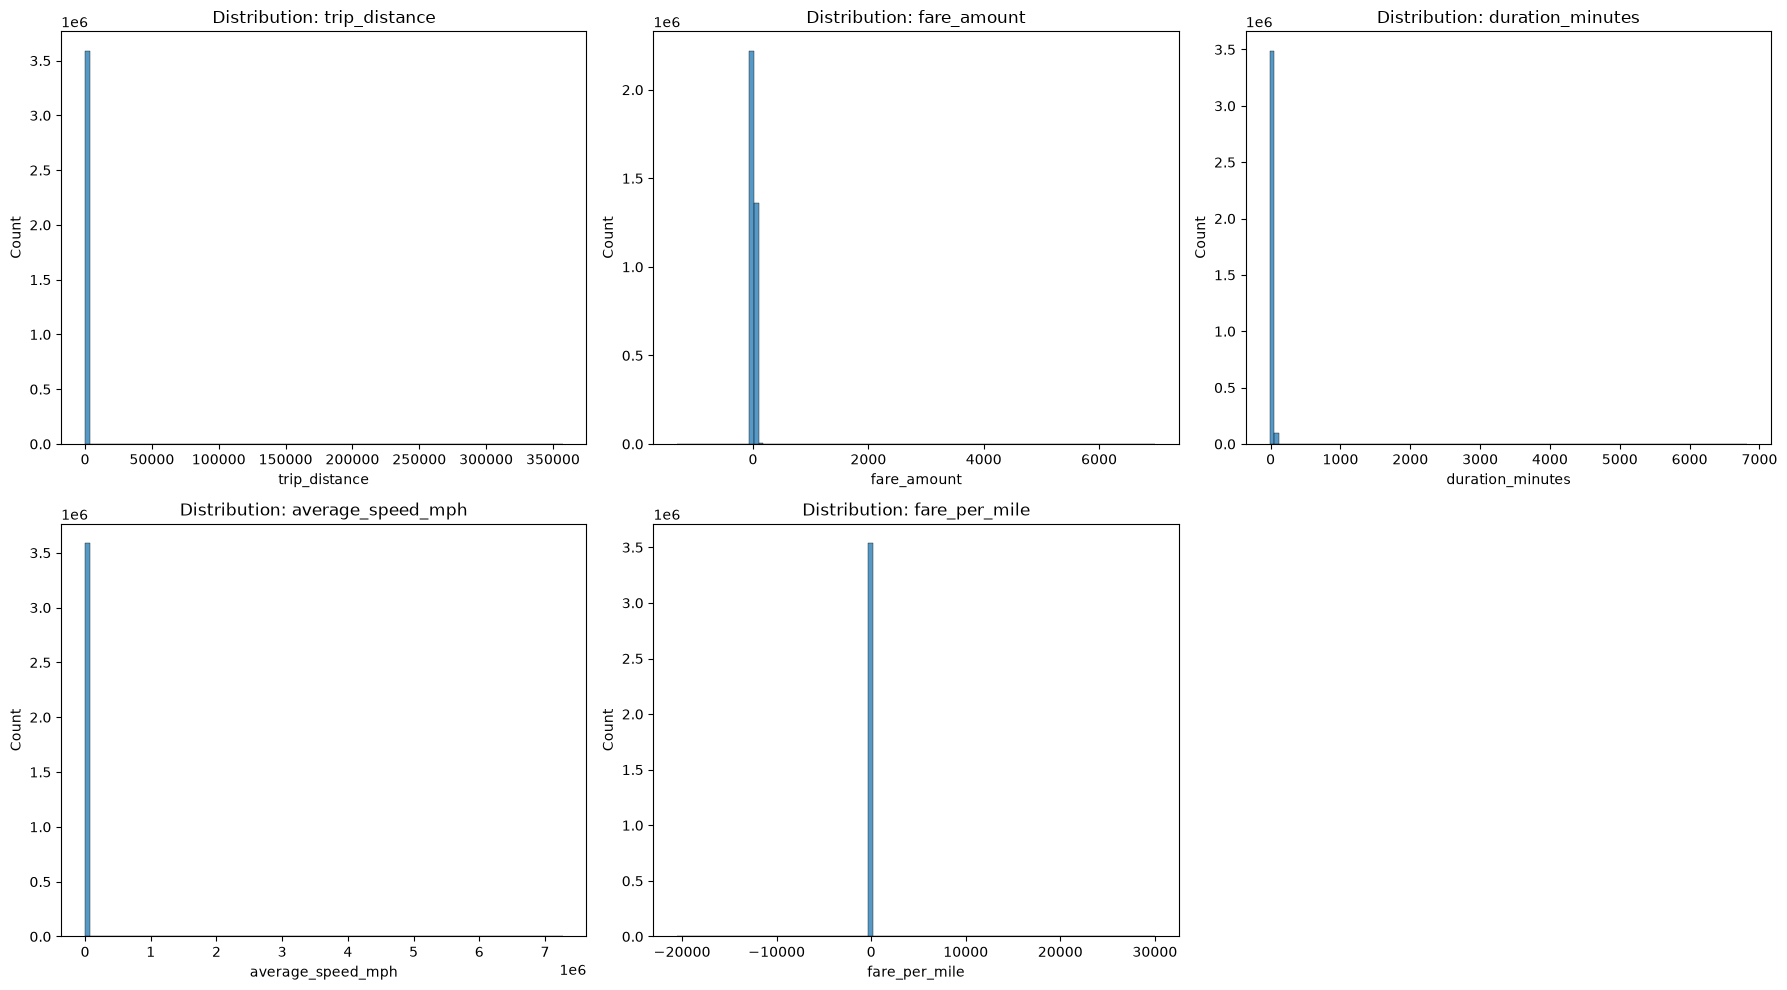

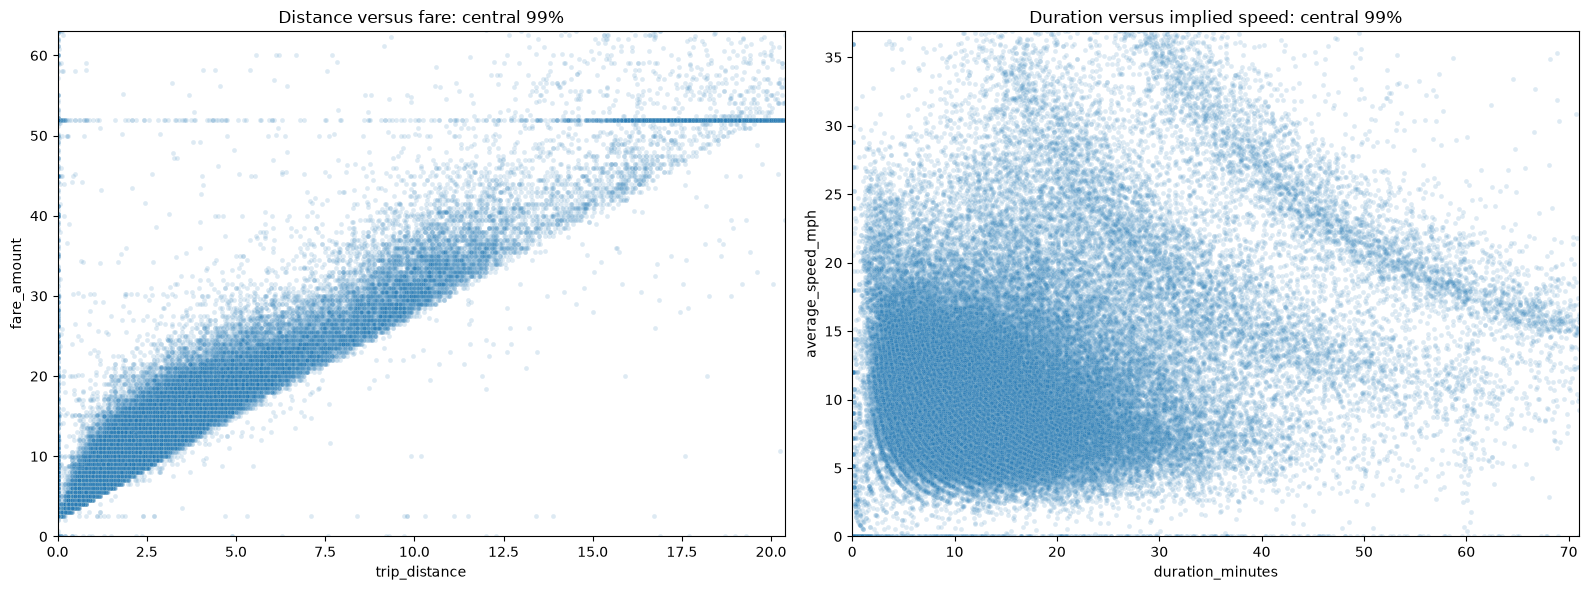

Share of complete dataset by time period:


,period,trip_count,percentage
0,Morning rush,351521,9.80
1,Evening rush,1053079,29.35
2,Weekend,970549,27.05
3,Outside rush hours,2183695,60.86


Note: Weekend can overlap with morning or evening rush; outside rush hours means neither rush period.


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

analysis_columns = [
    "trip_distance",
    "fare_amount",
    "duration_minutes",
    "average_speed_mph",
    "fare_per_mile",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for axis, column in zip(axes.flat, analysis_columns):
    sns.histplot(
        full_data[column].replace([float("inf"), -float("inf")], pd.NA).dropna(),
        bins=100,
        ax=axis,
    )
    axis.set_title(f"Distribution: {column}")
    axis.set_xlabel(column)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

plot_sample = full_data.sample(n=min(100_000, len(full_data)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    data=plot_sample,
    x="trip_distance",
    y="fare_amount",
    alpha=0.15,
    s=12,
    ax=axes[0],
)
axes[0].set_xlim(0, plot_sample["trip_distance"].quantile(0.99))
axes[0].set_ylim(0, plot_sample["fare_amount"].quantile(0.99))
axes[0].set_title("Distance versus fare: central 99%")
sns.scatterplot(
    data=plot_sample,
    x="duration_minutes",
    y="average_speed_mph",
    alpha=0.15,
    s=12,
    ax=axes[1],
)
axes[1].set_xlim(0, plot_sample["duration_minutes"].quantile(0.99))
axes[1].set_ylim(0, plot_sample["average_speed_mph"].quantile(0.99))
axes[1].set_title("Duration versus implied speed: central 99%")
plt.tight_layout()
plt.show()

outside_rush_hour = ~(
    full_data["is_morning_rush"].astype(bool)
    | full_data["is_evening_rush"].astype(bool)
)
period_summary = pd.DataFrame(
    {
        "period": [
            "Morning rush",
            "Evening rush",
            "Weekend",
            "Outside rush hours",
        ],
        "trip_count": [
            full_data["is_morning_rush"].sum(),
            full_data["is_evening_rush"].sum(),
            full_data["is_weekend"].sum(),
            outside_rush_hour.sum(),
        ],
    }
)
period_summary["percentage"] = (
    period_summary["trip_count"] / len(full_data) * 100
).round(2)

print("Share of complete dataset by time period:")
display(period_summary)
print(
    "Note: Weekend can overlap with morning or evening rush; "
    "outside rush hours means neither rush period."
)

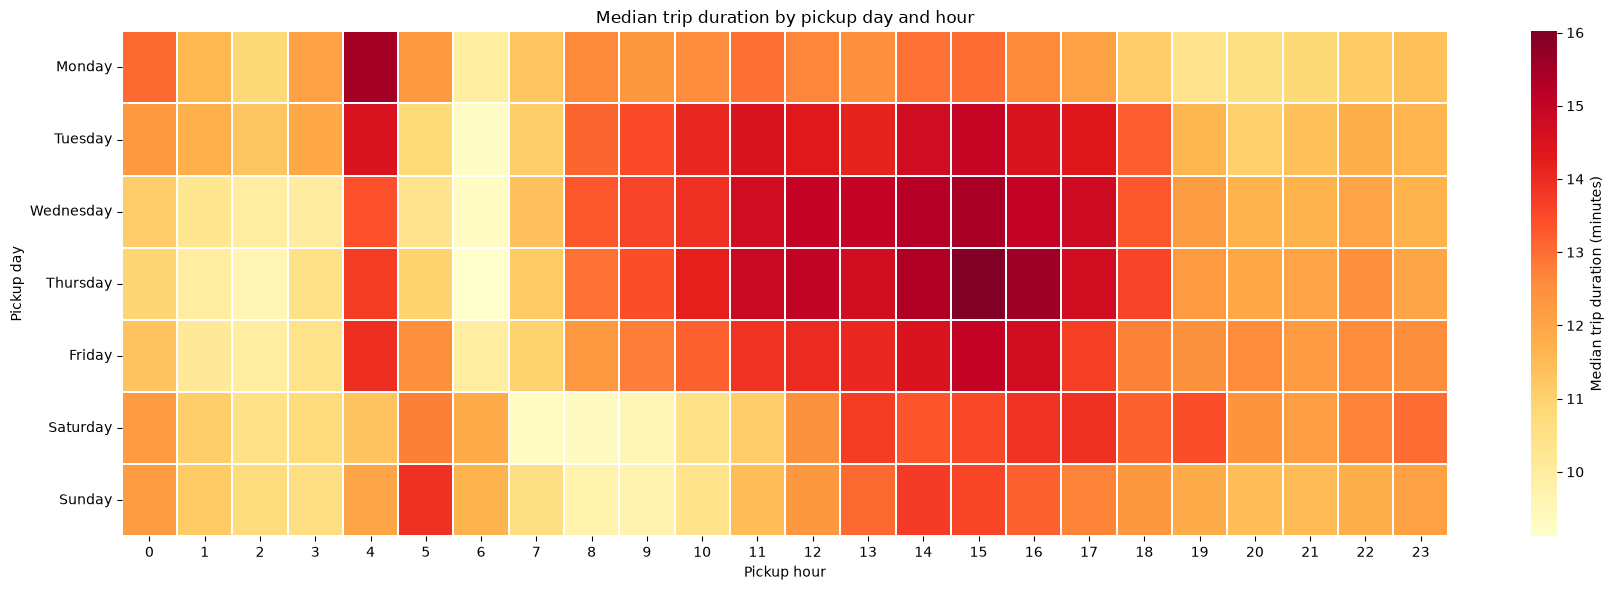

In [59]:
duration_by_day_hour = full_data.assign(
    pickup_day=full_data["tpep_pickup_datetime"].dt.dayofweek,
    pickup_hour=full_data["tpep_pickup_datetime"].dt.hour,
).pivot_table(
    index="pickup_day",
    columns="pickup_hour",
    values="duration_minutes",
    aggfunc="median",
)

duration_by_day_hour = duration_by_day_hour.reindex(index=range(7), columns=range(24))
duration_by_day_hour.index = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

plt.figure(figsize=(18, 6))
sns.heatmap(
    duration_by_day_hour,
    cmap="YlOrRd",
    linewidths=0.2,
    cbar_kws={"label": "Median trip duration (minutes)"},
)
plt.title("Median trip duration by pickup day and hour")
plt.xlabel("Pickup hour")
plt.ylabel("Pickup day")
plt.tight_layout()
plt.show()

Now prepared a heatmap showing correlations between the following features:  Day, Time and Vehicle speed.  The heatmap shows that the average speed is higher during the morning rush hour and lower during the evening rush hour

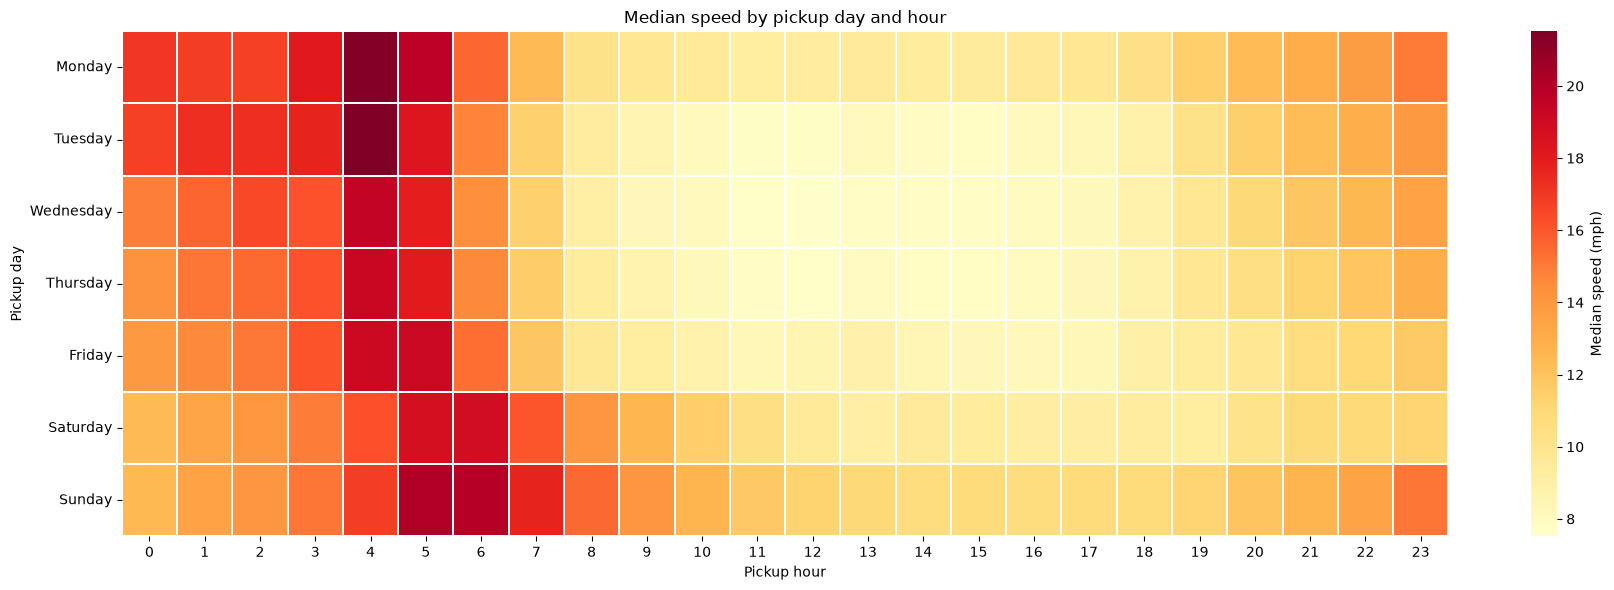

In [60]:
speed_by_day_hour = full_data.assign(
    pickup_day=full_data["tpep_pickup_datetime"].dt.dayofweek,
    pickup_hour=full_data["tpep_pickup_datetime"].dt.hour,
).pivot_table(
    index="pickup_day",
    columns="pickup_hour",
    values="average_speed_mph",
    aggfunc="median",
)

speed_by_day_hour = speed_by_day_hour.reindex(index=range(7), columns=range(24))
speed_by_day_hour.index = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

plt.figure(figsize=(18, 6))
sns.heatmap(
    speed_by_day_hour,
    cmap="YlOrRd",
    linewidths=0.2,
    cbar_kws={"label": "Median speed (mph)"},
)
plt.title("Median speed by pickup day and hour")
plt.xlabel("Pickup hour")
plt.ylabel("Pickup day")
plt.tight_layout()
plt.show()

,feature,lower_bound,upper_bound,outlier_count,outlier_percent
0,trip_distance,-2.720000,7.600000,455943,12.706397
1,fare_amount,-8.000000,32.000000,371211,10.345052
2,duration_minutes,-11.758333,40.041667,223768,6.236054
3,average_speed_mph,-2.112388,23.946178,223196,6.220113
4,fare_per_mile,0.453297,10.013736,153096,4.266539


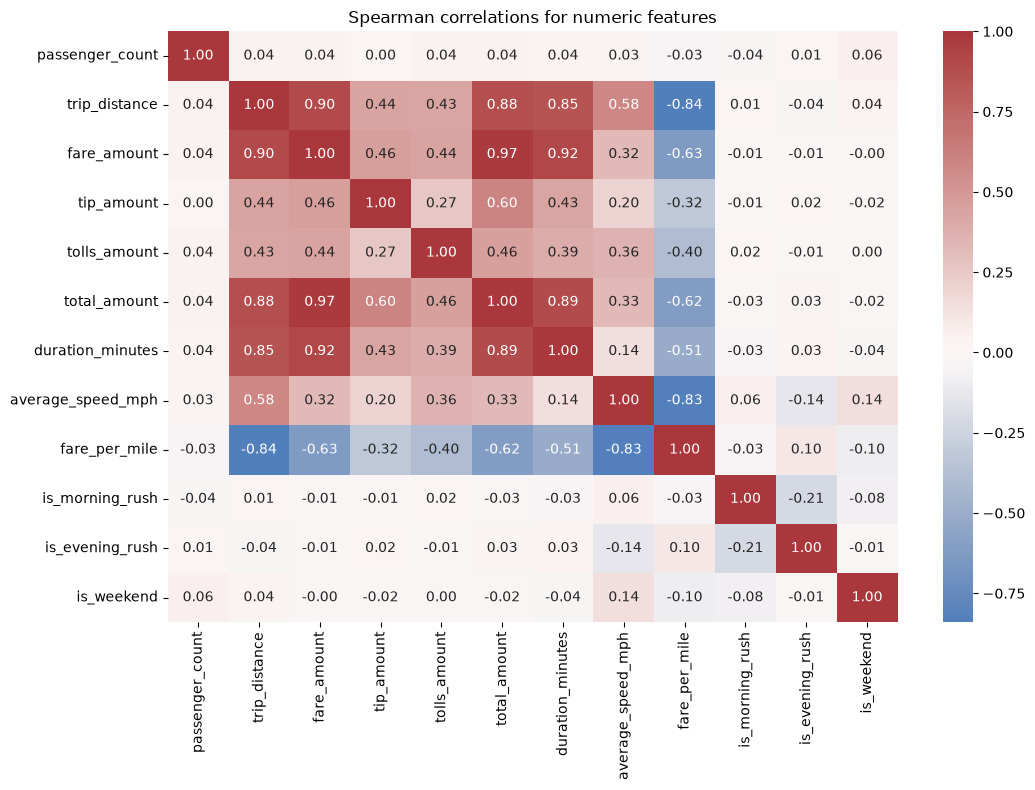

,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,duration_minutes,average_speed_mph,fare_per_mile,is_morning_rush,is_evening_rush,is_weekend
passenger_count,1.00,0.04,0.04,0.00,0.04,0.04,0.04,0.03,-0.03,-0.04,0.01,0.06
trip_distance,0.04,1.00,0.90,0.44,0.43,0.88,0.85,0.58,-0.84,0.01,-0.04,0.04
fare_amount,0.04,0.90,1.00,0.46,0.44,0.97,0.92,0.32,-0.63,-0.01,-0.01,-0.00
tip_amount,0.00,0.44,0.46,1.00,0.27,0.60,0.43,0.20,-0.32,-0.01,0.02,-0.02
tolls_amount,0.04,0.43,0.44,0.27,1.00,0.46,0.39,0.36,-0.40,0.02,-0.01,0.00
total_amount,0.04,0.88,0.97,0.60,0.46,1.00,0.89,0.33,-0.62,-0.03,0.03,-0.02
duration_minutes,0.04,0.85,0.92,0.43,0.39,0.89,1.00,0.14,-0.51,-0.03,0.03,-0.04
average_speed_mph,0.03,0.58,0.32,0.20,0.36,0.33,0.14,1.00,-0.83,0.06,-0.14,0.14
fare_per_mile,-0.03,-0.84,-0.63,-0.32,-0.40,-0.62,-0.51,-0.83,1.00,-0.03,0.10,-0.10
is_morning_rush,-0.04,0.01,-0.01,-0.01,0.02,-0.03,-0.03,0.06,-0.03,1.00,-0.21,-0.08


In [38]:
outlier_summary = []
for column in analysis_columns:
    values = full_data[column].replace([float("inf"), -float("inf")], pd.NA).dropna()
    first_quartile = values.quantile(0.25)
    third_quartile = values.quantile(0.75)
    iqr = third_quartile - first_quartile
    lower_bound = first_quartile - 1.5 * iqr
    upper_bound = third_quartile + 1.5 * iqr
    outlier_mask = (full_data[column] < lower_bound) | (full_data[column] > upper_bound)
    outlier_summary.append(
        {
            "feature": column,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_mask.sum(),
            "outlier_percent": outlier_mask.mean() * 100,
        }
    )

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "outlier_count", ascending=False
)
display(outlier_summary)

correlation_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "tolls_amount",
    "total_amount",
    "duration_minutes",
    "average_speed_mph",
    "fare_per_mile",
    'is_morning_rush',
    'is_evening_rush',
    'is_weekend'
]
correlation_matrix = full_data[correlation_columns].corr(method="spearman")

plt.figure(figsize=(11, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Spearman correlations for numeric features")
plt.tight_layout()
plt.show()

display(correlation_matrix.round(2))

In [61]:
low_distance_high_fare = full_data.loc[
    (full_data["trip_distance"] <= 2)
    & (full_data["fare_amount"] >= 50)
].sort_values("fare_amount", ascending=False)

long_distance_low_fare = full_data.loc[
    (full_data["trip_distance"] >= 20)
    & (full_data["fare_amount"] <= 50)
].sort_values("trip_distance", ascending=False)

review_columns = [
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "duration_minutes",
    "fare_amount",
    "fare_per_mile",
    "total_amount",
    "PULocationID",
    "DOLocationID",
]

print("Short trips with unusually high fares:")
display(low_distance_high_fare[review_columns].head(20))

print("Long trips with unusually low fares:")
display(long_distance_low_fare[review_columns].head(20))

full_data["review_distance_fare"] = (
    full_data.index.isin(low_distance_high_fare.index)
    | full_data.index.isin(long_distance_low_fare.index)
)
print(
    f"Trips flagged for distance/fare review: "
    f"{full_data['review_distance_fare'].sum():,}"
)

Short trips with unusually high fares:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,duration_minutes,fare_amount,fare_per_mile,total_amount,PULocationID,DOLocationID
1788460,2,2022-05-16 18:44:44,2022-05-16 18:44:56,0.00,0.200000,900.0,NaN,900.30,132,132
1779649,2,2022-05-16 17:25:00,2022-05-16 17:25:25,0.00,0.416667,900.0,NaN,900.30,98,98
2120531,2,2022-05-19 15:37:15,2022-05-19 17:54:25,1.01,137.166667,791.5,783.663366,794.80,230,169
2425688,2,2022-05-22 01:09:57,2022-05-22 01:17:12,0.00,7.250000,570.0,NaN,570.30,265,265
1595149,2,2022-05-14 22:01:55,2022-05-14 22:02:06,0.08,0.183333,535.0,6687.500000,535.30,265,265
2743767,2,2022-05-25 01:21:49,2022-05-25 01:21:59,0.00,0.166667,500.0,NaN,502.80,158,158
1755519,1,2022-05-16 14:07:56,2022-05-16 14:08:39,0.00,0.716667,500.0,NaN,500.30,193,193
1882687,1,2022-05-17 16:57:26,2022-05-17 17:00:19,0.00,2.883333,500.0,NaN,500.30,50,50
1234848,2,2022-05-12 04:18:01,2022-05-12 04:18:13,0.00,0.200000,500.0,NaN,500.30,265,265
736354,2,2022-05-07 16:01:15,2022-05-07 16:01:23,0.00,0.133333,500.0,NaN,500.30,265,265


Long trips with unusually low fares:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,duration_minutes,fare_amount,fare_per_mile,total_amount,PULocationID,DOLocationID
3528934,2,2022-05-15 18:45:00,2022-05-15 18:57:00,357192.65,12.0,12.46,0.000035,20.13,249,137
3469281,2,2022-05-03 09:33:00,2022-05-03 09:55:00,333632.96,22.0,16.51,0.000049,23.10,24,43
3482491,2,2022-05-06 07:24:00,2022-05-06 07:43:00,281179.94,19.0,34.76,0.000124,51.37,116,138
3543592,2,2022-05-19 15:54:00,2022-05-19 16:04:00,275692.34,10.0,8.89,0.000032,13.54,238,236
3559850,2,2022-05-23 07:47:00,2022-05-23 08:17:00,255753.73,30.0,32.40,0.000127,48.48,42,138
3510464,2,2022-05-12 07:31:00,2022-05-12 07:42:00,237129.53,11.0,11.65,0.000049,18.26,79,87
3567952,2,2022-05-25 18:36:00,2022-05-25 19:07:00,201873.37,31.0,28.65,0.000142,39.04,50,87
3541817,2,2022-05-19 07:46:00,2022-05-19 08:09:00,191630.40,23.0,26.81,0.000140,33.11,33,162
3557391,2,2022-05-22 12:08:00,2022-05-22 12:36:00,178999.27,28.0,22.66,0.000127,30.31,231,37
3532408,2,2022-05-16 18:02:00,2022-05-16 18:22:00,159097.41,20.0,15.43,0.000097,21.86,33,79


Trips flagged for distance/fare review: 20,095


## Final insights and cleaning decisions

### 1. Scope and data coverage

- The complete May 2022 dataset contains **3,588,295 trips** and was analyzed across all four row groups.
- The first row group was useful for an initial inspection, but it was not sufficient for estimating missing values or outlier rates for the entire dataset.

### 2. Missing values and repeated patterns

- **3,414,206 trips (95.15%)** have no missing values.
- **129,524 trips (3.61%)** share the same missing fields: `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, and `airport_fee`.
- This repeated pattern suggests a common source or ingestion issue rather than independent random missingness. These columns should not automatically cause a row to be deleted.
- `average_speed_mph` is missing when the duration is not positive, and `fare_per_mile` is missing when the distance is not positive. Those are derived missing values caused by invalid denominators, not necessarily independent data loss.
- Recommended treatment: preserve the original columns, add missingness indicators if they are used as model inputs, and impute only when the model and business meaning justify it. Investigate whether the five-column pattern is associated with a particular vendor, time period, payment type, or location.

### 3. Most useful features for fare prediction

Potentially useful features known at or before pickup:

- `PULocationID` and `DOLocationID` for route and zone effects.
- `trip_distance` as a primary fare driver.
- `tpep_pickup_datetime`, transformed into pickup hour, day of week, and month.
- `passenger_count`, with missingness and zero values treated explicitly.
- `RatecodeID`, after checking its missingness pattern.
- `VendorID` and `store_and_fwd_flag` as operational indicators, if they improve validation performance.

For a realistic prediction task, avoid using information only known after the trip, such as `tpep_dropoff_datetime`, `tip_amount`, `tolls_amount`, `total_amount`, `payment_type`, `mta_tax`, `improvement_surcharge`, `congestion_surcharge`, and `airport_fee`. Using them would create target leakage.

### 4. Outliers and unusual trips

The IQR method identified many statistical outliers, but an IQR flag is not automatically a data error because taxi trips are naturally skewed:

- `trip_distance`: 455,943 IQR outliers (12.71%).
- `fare_amount`: 371,211 IQR outliers (10.35%).
- `duration_minutes`: 223,768 IQR outliers (6.24%).
- `average_speed_mph`: 223,196 IQR outliers (6.22%).
- `fare_per_mile`: 153,096 IQR outliers (4.27%).

The most important anomalies are not merely high IQR values. The complete-data inspection found records such as:

- trips with `trip_distance` equal to zero and fares of hundreds of dollars;
- trips shorter than two miles with very high fares;
- trips with distances above 100,000 miles but ordinary fares, which are physically impossible and indicate corrupted distance values;
- unusually high `fare_per_mile` values caused by very short distances.

There are **20,095 trips** flagged by the current distance/fare review rules. These records should be inspected, and the extreme distance records should be removed from the training data unless the source data can be corrected.

### 5. Correlation findings

Spearman correlation shows the strongest relationships among the numeric variables are:

- `fare_amount` and `total_amount`: **0.97**, which is expected because total amount contains the fare and should not be used as an input when predicting fare.
- `trip_distance` and `fare_amount`: **0.90**, making distance one of the strongest candidate features.
- `duration_minutes` and `fare_amount`: **0.92**, although dropoff time is unavailable before the ride and therefore cannot be used for a realistic pre-trip model.
- `trip_distance` and `duration_minutes`: **0.85**, showing that the derived duration is closely related to distance but still should be checked for leakage.

Correlation does not prove causality and does not replace validation. It is especially important to remove post-trip variables before interpreting model performance.

### 6. What should be deleted or retained?

Delete from the modeling dataset, or quarantine for separate review:

- rows with pickup or dropoff dates outside May 2022;
- rows with zero or negative duration;
- rows with zero or negative trip distance;
- rows with zero or negative `fare_amount` when training a positive-fare prediction target;
- rows with impossible distances or speeds, such as the extreme corrupted distances found above;
- duplicate rows, after checking whether they are true duplicates or legitimate repeated records.

Do **not** delete every IQR outlier. First apply domain rules and inspect the most extreme records. Do not delete rows only because `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, or `airport_fee` are missing; that repeated pattern may contain useful information about how the data was collected.

### 7. Important checks still to complete

Before producing the final training dataset, also verify:

- whether `total_amount` equals the expected sum of fare, taxes, tips, tolls, surcharges, and fees;
- whether pickup and dropoff location IDs are valid and whether identical locations are plausible for zero-distance trips;
- whether records are duplicated;
- whether missingness is concentrated by vendor, hour, date, location, or payment type;
- whether extreme records remain after cleaning;
- whether the final train/validation split is chronological to avoid using future trips to predict earlier trips.

The recommended result is a cleaned dataset plus a separate review table of quarantined anomalies, rather than silently deleting every unusual observation.

In [ ]:
from scripts.data_cleaner import TaxiDataCleaner

cleaner = TaxiDataCleaner(
    dataset=full_data,
    # The month is explicit for this May 2022 file; the cleaner has no May 2022 default.
    dataset_month="2022-05",
    max_duration_minutes=180,
    max_speed_mph=80,
    max_trip_distance_miles=1000,
    remove_duplicates=True,
)

cleaned_data = cleaner.clean()

print(f"Rows before cleaning: {len(full_data):,}")
print(f"Rows after cleaning: {len(cleaned_data):,}")
print(f"Rows removed: {len(full_data) - len(cleaned_data):,}")
print("cleaned_data is ready for later database persistence.")

In [ ]:
from scripts.model_data_builder import TaxiModelDataBuilder

model_builder = TaxiModelDataBuilder(cleaned_data=cleaned_data)
model_data = model_builder.build()

print(f"Model dataset shape: {model_data.shape}")
print("Model features and target:")
print(list(model_data.columns))
print("model_data is ready for model training.")